# softmax 回归 · 从零开始实现（PyTorch）

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「图像分类数据集 + softmax 回归的从零开始实现」
> 🎯 **目标**：手写 softmax 回归，在 **Fashion-MNIST**（10 类服装图片）上做**多分类**，理解 softmax 为什么是分类任务的标配输出。

## 从「回归」到「多分类」

线性回归输出**一个连续数**；而分类要输出**属于每个类别的概率**（10 个类别就输出 10 个概率，加起来等于 1）。softmax 就是「把 10 个分数变成 10 个概率」的函数：

$$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$$

> 🔑 **记忆**：softmax 回归 = 线性层（算分数）+ softmax（变概率）+ 交叉熵（算损失）。首次运行会自动下载 Fashion-MNIST 数据集（约 30MB）。


In [3]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt
!pip install torchvision -q
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 1. 加载 Fashion-MNIST：10 类服装的 28×28 灰度图

`torchvision.datasets.FashionMNIST` 封装好了下载和读取。图片是 28×28 灰度图，我们把它**展平成 784 维向量**（28×28=784）喂给模型。


In [4]:
# ---- 加载 Fashion-MNIST ----
from torchvision import datasets, transforms
from torch.utils import data

def load_data_fashion_mnist(batch_size, root='../data'):
    trans = transforms.ToTensor()   # 把 PIL 图片转成 Tensor，像素值缩放到 [0,1]
    mnist_train = datasets.FashionMNIST(root=root, train=True,  transform=trans, download=True)
    mnist_test  = datasets.FashionMNIST(root=root, train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True),
            data.DataLoader(mnist_test,  batch_size, shuffle=False))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

类别名 = ['T恤', '裤子', '套头衫', '连衣裙', '外套', '凉鞋', '衬衫', '运动鞋', '包', '短靴']
print("训练集样本数：", len(train_iter.dataset), "| 测试集样本数：", len(test_iter.dataset))

# 看一眼第一张图长什么样
for X, y in train_iter:
    print("一个 batch 的 X 形状：", tuple(X.shape), "（batch, 通道, 高, 宽）")
    print("标签 y 形状：", tuple(y.shape))
    break


训练集样本数： 60000 | 测试集样本数： 10000
一个 batch 的 X 形状： (256, 1, 28, 28) （batch, 通道, 高, 宽）
标签 y 形状： (256,)


## 2. 看一眼数据：10 类服装长什么样

把一个小批量的图片画出来，每张图上方标出它的类别。这样训练前对数据有个直观认识。


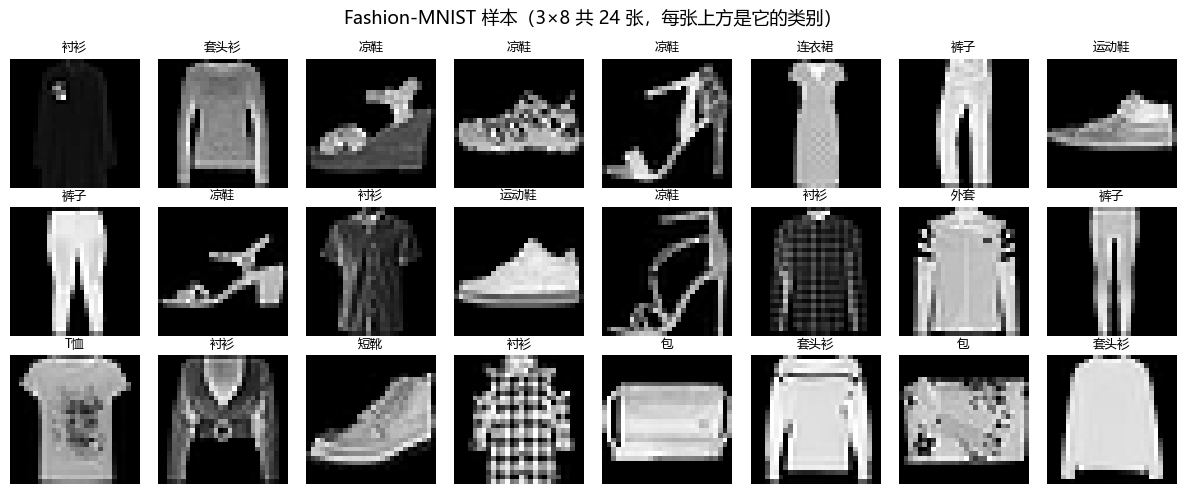

In [5]:
# ---- 可视化一个小批量的样本 ----
X, y = next(iter(train_iter))
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = X[i].squeeze()            # 去掉通道维，得到 28×28
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(类别名[y[i].item()], fontsize=9)
    ax.axis('off')
fig.suptitle('Fashion-MNIST 样本（3×8 共 24 张，每张上方是它的类别）', fontsize=13)
plt.tight_layout(); plt.show()


## 3. 从零实现：softmax、模型、交叉熵、准确率

全部手写，不碰 `torch.nn`：
- **softmax**：先减去每行最大值（防溢出），再 `exp` 归一化；
- **模型**：`net(X) = softmax(X·W + b)`，把 784 维展平后做矩阵乘，得到 10 个分数；
- **交叉熵损失**：只取「真实类别」那一个概率的负对数 `-log(ŷ[y])`；
- **准确率**：预测类别 = 分数最大的那个下标，和真实标签比对的命中率。


In [6]:
# ---- 从零实现 softmax 回归的四个零件 ----
num_inputs, num_outputs = 784, 10
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

def softmax(X):
    '''把每行变成和为 1 的概率分布。减去最大值是为了数值稳定，防止 exp 溢出。'''
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)
    return X_exp / X_exp.sum(dim=1, keepdim=True)

def net(X):
    '''模型：展平 784 维 → 线性变换 → softmax。'''
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

def cross_entropy(y_hat, y):
    '''交叉熵损失：对每个样本，取「真实类别」对应概率的负对数。'''
    return -torch.log(y_hat[range(len(y_hat)), y])

def accuracy(y_hat, y):
    '''准确率：预测类别（概率最大者）与真实标签一致的占比。'''
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    return float((y_hat.type(y.dtype) == y).type(y.dtype).sum())

def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 小测试：softmax 输出是否真的和为 1
样例 = softmax(torch.tensor([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]]))
print("softmax 输出：\n", 样例)
print("每行求和：", 样例.sum(dim=1), "（应该都是 1）")


softmax 输出：
 tensor([[0.6590, 0.2424, 0.0986],
        [0.3333, 0.3333, 0.3333]])
每行求和： tensor([1.0000, 1.0000]) （应该都是 1）


## 4. 训练循环：10 轮，观察训练损失和准确率

每一轮遍历整个训练集：每个 batch 做「前向 → 反向 → 更新」。每轮结束统计一次训练集的**平均损失**和**准确率**。


In [7]:
# ---- 训练 10 轮 ----
lr, num_epochs = 0.1, 10

for epoch in range(num_epochs):
    # 训练：遍历所有 batch
    for X, y in train_iter:
        l = cross_entropy(net(X), y)
        l.sum().backward()
        sgd([W, b], lr, batch_size)
    # 评估：统计训练集上的损失和准确率
    with torch.no_grad():
        总损失, 总命中, 总数 = 0.0, 0.0, 0
        for X, y in train_iter:
            y_hat = net(X)
            总损失 += float(cross_entropy(y_hat, y).sum())
            总命中 += accuracy(y_hat, y)
            总数 += y.numel()
        print(f"epoch {epoch+1:2d}: 训练损失 {总损失/总数:.4f}, 训练准确率 {总命中/总数:.4f}")


epoch  1: 训练损失 0.6060, 训练准确率 0.8013
epoch  2: 训练损失 0.5392, 训练准确率 0.8254
epoch  3: 训练损失 0.5064, 训练准确率 0.8307
epoch  4: 训练损失 0.4877, 训练准确率 0.8367
epoch  5: 训练损失 0.4746, 训练准确率 0.8413
epoch  6: 训练损失 0.4690, 训练准确率 0.8418
epoch  7: 训练损失 0.4574, 训练准确率 0.8451
epoch  8: 训练损失 0.4498, 训练准确率 0.8481
epoch  9: 训练损失 0.4511, 训练准确率 0.8468
epoch 10: 训练损失 0.4487, 训练准确率 0.8477


## 5. 在测试集上评估 + 可视化预测

模型从来没「见过」测试集，用它来检验泛化能力。最后抽几张测试图片，看看模型预测对不对（绿字=对，红字=错）。


测试集准确率：0.8334


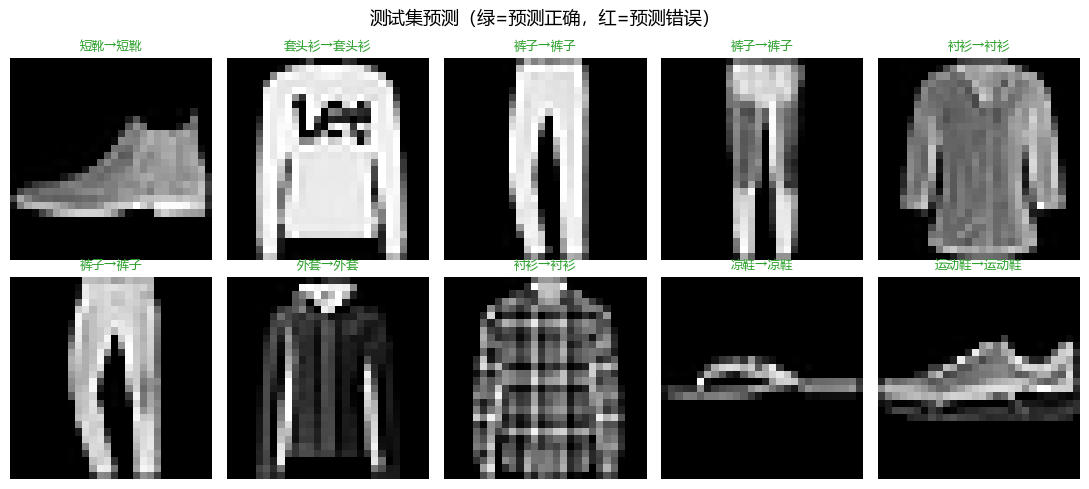

In [8]:
# ---- 测试集准确率 ----
with torch.no_grad():
    总命中, 总数 = 0.0, 0
    for X, y in test_iter:
        总命中 += accuracy(net(X), y)
        总数 += y.numel()
print(f"测试集准确率：{总命中/总数:.4f}")

# ---- 可视化：抽一批测试样本看预测对不对 ----
X, y = next(iter(test_iter))
with torch.no_grad():
    预测 = net(X).argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].squeeze().numpy(), cmap='gray')
    对错 = '对' if 预测[i] == y[i] else '错'
    color = 绿 if 预测[i] == y[i] else 红
    ax.set_title(f"{类别名[y[i].item()]}→{类别名[预测[i].item()]}", color=color, fontsize=9)
    ax.axis('off')
fig.suptitle('测试集预测（绿=预测正确，红=预测错误）', fontsize=13)
plt.tight_layout(); plt.show()
